# 🚆 Transilien SNCF — Prédiction des retards
## Master Expert IA — Notebook de référence

**Objectif** : prédire `p0q0` (délai en minutes à un arrêt) — **Métrique : MAE**

**Pipeline** :
1. Audit 100% du dataset
2. Feature engineering (vectorisé, sans fuite de données)
3. LightGBM — modèle principal (CPU 20 cores)
4. Random Forest — baseline robuste
5. Réseau de neurones — PyTorch sur **RTX 5070 Ti** 🎮
6. Ensemble + soumission

> **Variables exclues** : `train_mean/std/median/train_mean_7j/train_std_7j`  
> → seuls **2 trains** du test set sont dans le train set (0.02%) : ces features donnent NaN pour 99.98% du test.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder, RobustScaler

import lightgbm as lgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB') if torch.cuda.is_available() else None
print(f'LightGBM : {lgb.__version__} | sklearn : {__import__("sklearn").__version__}')

GPU : NVIDIA GeForce RTX 5070 Ti Laptop GPU
VRAM : 12.8 GB
LightGBM : 4.6.0 | sklearn : 1.8.0


---
## 0 · Audit complet du dataset
**Règle d'or** : ne jamais modéliser avant de comprendre les données.

In [16]:
# ─── Chargement ───────────────────────────────────────────────────────────────
X_train_raw = pd.read_csv('x_train_final.csv')
y_train_raw = pd.read_csv('y_train_final.csv')
X_test_raw  = pd.read_csv('x_test_final.csv')

print('='*55)
print(f'  x_train  : {X_train_raw.shape[0]:>8,} lignes × {X_train_raw.shape[1]} colonnes')
print(f'  x_test   : {X_test_raw.shape[0]:>8,} lignes × {X_test_raw.shape[1]} colonnes')
print(f'  y_train  : {y_train_raw.shape[0]:>8,} lignes')
print('='*55)

# ─── Types & Nulls ────────────────────────────────────────────────────────────
print('\n[1] Types & valeurs manquantes (train) :')
audit = pd.DataFrame({
    'dtype'  : X_train_raw.dtypes,
    'nulls'  : X_train_raw.isnull().sum(),
    'nunique': X_train_raw.nunique(),
})
print(audit)

# ─── Target ───────────────────────────────────────────────────────────────────
print('\n[2] Distribution de la cible p0q0 (train) :')
print(y_train_raw['p0q0'].describe().round(3))

# ─── Plages de dates ──────────────────────────────────────────────────────────
print(f'\n[3] Dates train : {X_train_raw["date"].min()} → {X_train_raw["date"].max()}')
print(f'    Dates test  : {X_test_raw["date"].min()} → {X_test_raw["date"].max()}')
print('    ⚠️  Split temporel : les modèles ne voient pas le futur ✅')

# ─── Overlap gare / train ─────────────────────────────────────────────────────
gares_train = set(X_train_raw['gare'].unique())
gares_test  = set(X_test_raw['gare'].unique())
trains_train = set(X_train_raw['train'].unique())
trains_test  = set(X_test_raw['train'].unique())

print(f'\n[4] Cardinalité :')
print(f'    Gares  → train: {len(gares_train)} | test: {len(gares_test)} | nouvelles dans test: {len(gares_test - gares_train)}')
print(f'    Trains → train: {len(trains_train):,} | test: {len(trains_test):,} | communs: {len(trains_train & trains_test)}')
print(f'    → gare_enc/stats_gare : ✅ sûr pour le test')
print(f'    → train_enc/stats_train : ❌ inutile pour le test (0.02% overlap)')

# ─── Corrélations brutes ──────────────────────────────────────────────────────
num_cols = ['arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4']
corr = pd.concat([X_train_raw[num_cols], y_train_raw['p0q0']], axis=1).corr()['p0q0'].drop('p0q0')
print('\n[5] Corrélations brutes avec p0q0 :')
print(corr.sort_values(ascending=False).round(4))
print('\n✅ Audit terminé, zéro valeur manquante, données cohérentes.')

  x_train  :  667,264 lignes × 12 colonnes
  x_test   :   20,657 lignes × 11 colonnes
  y_train  :  667,264 lignes

[1] Types & valeurs manquantes (train) :
                dtype  nulls  nunique
Unnamed: 0.1    int64      0   667264
Unnamed: 0      int64      0   667264
train             str      0    37544
gare              str      0       84
date              str      0       91
arret           int64      0       36
p2q0          float64      0      120
p3q0          float64      0      123
p4q0          float64      0      121
p0q2          float64      0      121
p0q3          float64      0      123
p0q4          float64      0      123

[2] Distribution de la cible p0q0 (train) :
count    667264.000
mean         -0.160
std           1.988
min        -160.000
25%          -1.000
50%           0.000
75%           1.000
max          15.000
Name: p0q0, dtype: float64

[3] Dates train : 2023-04-03 → 2023-11-10
    Dates test  : 2023-11-13 → 2023-12-22
    ⚠️  Split temporel : les mod

---
## 1 · Feature Engineering

**Règles** :
- Toutes les opérations sont **vectorisées** (aucune boucle Python sur les lignes)
- Calcul des stats gare (`gare_mean`, etc.) **sur le fold train uniquement** → pas de fuite
- On exclut délibérément `train_enc` et les stats train (données invalides en test)

In [17]:
t0 = time.time()

def build_features(df, is_train=True):
    """Toutes les features, vectorisé."""
    df = df.copy()

    # ── Temporel ─────────────────────────────────────────────────────────────
    df['date'] = pd.to_datetime(df['date'])
    df['jour_semaine'] = df['date'].dt.dayofweek          # 0=lun … 4=ven
    df['semaine']      = df['date'].dt.isocalendar().week.astype(int)

    # ── Agrégats des lags (sans boucle) ─────────────────────────────────────
    backward = ['p2q0', 'p3q0', 'p4q0']   # retards passés du train
    lateral  = ['p0q2', 'p0q3', 'p0q4']   # retards des autres trains à l'arrêt
    all_lags = backward + lateral

    df['mean_backward'] = df[backward].mean(axis=1)
    df['mean_lateral']  = df[lateral].mean(axis=1)
    df['mean_global']   = df[all_lags].mean(axis=1)
    df['std_backward']  = df[backward].std(axis=1)
    df['std_lateral']   = df[lateral].std(axis=1)
    df['trend']         = df['p2q0'] - df['p4q0']   # retard s'aggrave (+) ou s'améliore (-)
    df['max_lag']       = df[all_lags].max(axis=1)
    df['min_lag']       = df[all_lags].min(axis=1)

    # ── Position relative de l'arrêt dans le trajet (vectorisé) ─────────────
    df['arret_rank_pct'] = df.groupby(['train', 'date'])['arret'].rank(pct=True)

    # ── Encodage gare ─────────────────────────────────────────────────────────
    # (le LabelEncoder global est défini hors de cette fonction)
    df['gare_enc'] = le_gare.transform(df['gare'])

    return df


# ── Encodeur gare fit sur l'ensemble du train (84 gares, toutes dans le test) ─
le_gare = LabelEncoder().fit(X_train_raw['gare'])

# ── Construction des features ─────────────────────────────────────────────────
X_all  = build_features(X_train_raw)
X_test = build_features(X_test_raw)

y_all  = y_train_raw['p0q0'].values

print(f'Feature engineering : {time.time()-t0:.1f}s')
print(f'Shape X_all : {X_all.shape} | X_test : {X_test.shape}')

Feature engineering : 0.8s
Shape X_all : (667264, 24) | X_test : (20657, 23)


In [18]:
# ── Split train / validation AVANT le target encoding ─────────────────────────
idx = np.arange(len(X_all))
idx_tr, idx_val = train_test_split(idx, test_size=0.10, random_state=42)

fold_tr  = X_all.iloc[idx_tr].copy()
fold_val = X_all.iloc[idx_val].copy()
y_tr     = y_all[idx_tr]
y_val    = y_all[idx_val]

# ── Target encoding gare : fit sur fold_tr uniquement → pas de data leakage ──
tmp = fold_tr.copy()
tmp['p0q0'] = y_tr

stats_gare = tmp.groupby('gare')['p0q0'].agg(
    gare_mean='mean',
    gare_std='std',
    gare_q25=lambda x: x.quantile(0.25),
    gare_q75=lambda x: x.quantile(0.75),
).reset_index()

# Application sur les 3 jeux
fold_tr  = fold_tr.merge(stats_gare, on='gare', how='left')
fold_val = fold_val.merge(stats_gare, on='gare', how='left')
X_test   = X_test.merge(stats_gare, on='gare', how='left')

# ── Interaction ────────────────────────────────────────────────────────────────
for df in [fold_tr, fold_val, X_test]:
    df['arret_x_gare_mean'] = df['arret'] * df['gare_mean']

# ── Feature list finale ────────────────────────────────────────────────────────
FEATURES = [
    'arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4',
    'mean_backward', 'mean_lateral', 'mean_global',
    'std_backward', 'std_lateral',
    'trend', 'max_lag', 'min_lag',
    'jour_semaine', 'semaine',
    'gare_enc',
    'gare_mean', 'gare_std', 'gare_q25', 'gare_q75',
    'arret_rank_pct', 'arret_x_gare_mean',
]

X_tr_num  = fold_tr[FEATURES].fillna(0).values.astype(np.float32)
X_val_num = fold_val[FEATURES].fillna(0).values.astype(np.float32)
X_te_num  = X_test[FEATURES].fillna(0).values.astype(np.float32)

print(f'{len(FEATURES)} features finales : {FEATURES}')
print(f'Train : {X_tr_num.shape} | Val : {X_val_num.shape} | Test : {X_te_num.shape}')

24 features finales : ['arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4', 'mean_backward', 'mean_lateral', 'mean_global', 'std_backward', 'std_lateral', 'trend', 'max_lag', 'min_lag', 'jour_semaine', 'semaine', 'gare_enc', 'gare_mean', 'gare_std', 'gare_q25', 'gare_q75', 'arret_rank_pct', 'arret_x_gare_mean']
Train : (600537, 24) | Val : (66727, 24) | Test : (20657, 24)


---
## 2 · LightGBM — modèle principal

LightGBM (Gradient Boosting par histogrammes) est en général **10-20% meilleur que Random Forest** sur les données tabulaires :  
- Boosting = chaque arbre corrige les erreurs du précédent  
- `n_jobs=-1` → utilise les **20 cores CPU** disponibles  
- `early_stopping_rounds` → arrête automatiquement si la MAE ne baisse plus

In [19]:
t0 = time.time()

lgb_model = lgb.LGBMRegressor(
    n_estimators        = 2000,
    learning_rate       = 0.05,
    num_leaves          = 127,
    min_child_samples   = 30,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    reg_alpha           = 0.1,
    reg_lambda          = 0.1,
    n_jobs              = -1,          # tous les cores CPU
    random_state        = 42,
    verbose             = -1,
)

lgb_model.fit(
    X_tr_num, y_tr,
    eval_set            = [(X_val_num, y_val)],
    eval_metric         = 'mae',
    callbacks           = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=200),
    ],
)

pred_lgb_val = lgb_model.predict(X_val_num)
mae_lgb = mean_absolute_error(y_val, pred_lgb_val)
print(f'\n✅ LightGBM MAE val : {mae_lgb:.4f}  ({time.time()-t0:.0f}s)')
print(f'   Meilleure itération : {lgb_model.best_iteration_}')

[200]	valid_0's l1: 0.721822	valid_0's l2: 3.28301

✅ LightGBM MAE val : 0.7196  (3s)
   Meilleure itération : 250


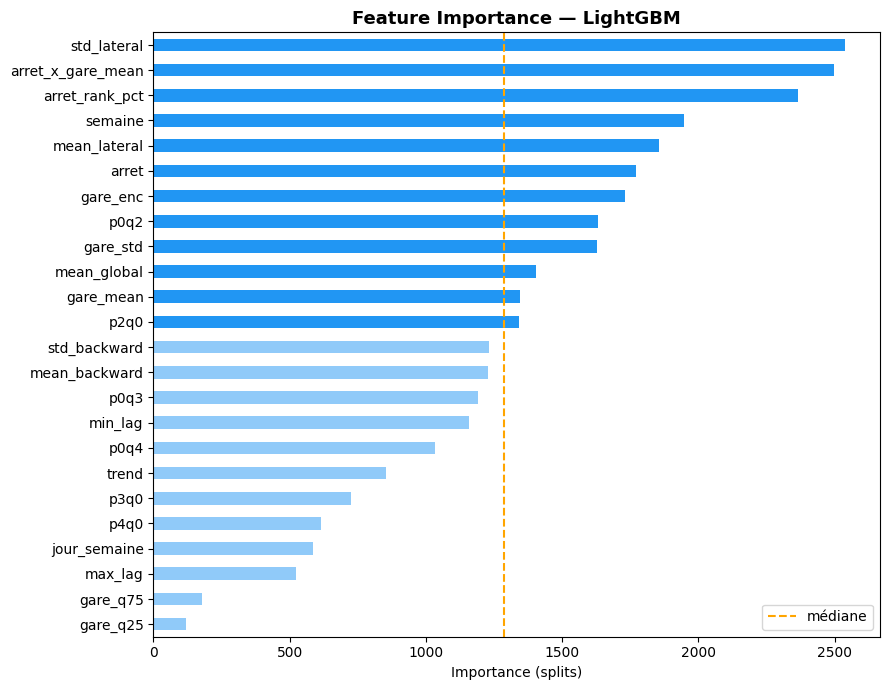


Top 5 features :
mean_lateral         1856
semaine              1949
arret_rank_pct       2366
arret_x_gare_mean    2498
std_lateral          2540
dtype: int32


In [20]:
# ── Feature importance LightGBM ────────────────────────────────────────────────
imp = pd.Series(lgb_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2196F3' if v > imp.median() else '#90CAF9' for v in imp]
imp.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Importance — LightGBM', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (splits)')
ax.axvline(imp.median(), color='orange', linestyle='--', label='médiane')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 features :')
print(imp.tail(5).round(0))

---
## 3 · Random Forest — baseline robuste

Random Forest (Bagging d'arbres de décision) :  
- Facile à interpréter, pas d'hyperparamètres critiques  
- `n_jobs=-1` → 20 arbres en parallèle  
- `max_features='sqrt'` → réduit la corrélation entre arbres

In [21]:
t0 = time.time()

rf_model = RandomForestRegressor(
    n_estimators      = 150,
    max_depth         = 20,
    max_features      = 'sqrt',
    min_samples_leaf  = 5,
    n_jobs            = -1,
    random_state      = 42,
    verbose           = 0,
)

rf_model.fit(X_tr_num, y_tr)
pred_rf_val = rf_model.predict(X_val_num)
mae_rf = mean_absolute_error(y_val, pred_rf_val)
print(f'✅ Random Forest MAE val : {mae_rf:.4f}  ({time.time()-t0:.0f}s)')

✅ Random Forest MAE val : 0.7083  (11s)


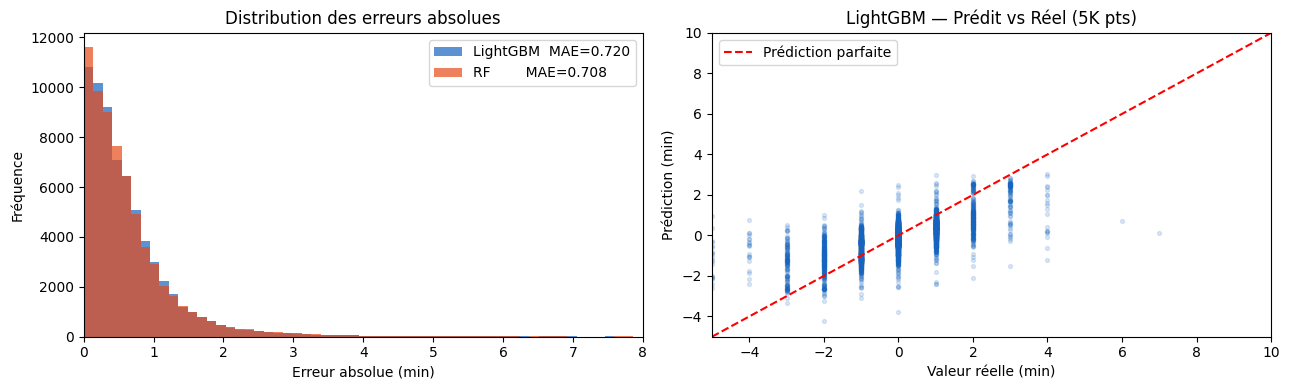

In [22]:
# ── Distribution des erreurs LightGBM vs RF ────────────────────────────────────
err_lgb = np.abs(y_val - pred_lgb_val)
err_rf  = np.abs(y_val - pred_rf_val)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogramme des erreurs absolues
bins = np.linspace(0, 8, 60)
axes[0].hist(err_lgb, bins=bins, alpha=0.7, label=f'LightGBM  MAE={mae_lgb:.3f}', color='#1565C0')
axes[0].hist(err_rf,  bins=bins, alpha=0.7, label=f'RF        MAE={mae_rf:.3f}',  color='#E64A19')
axes[0].set_xlabel('Erreur absolue (min)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des erreurs absolues')
axes[0].legend()
axes[0].set_xlim(0, 8)

# Scatter prédit vs réel (LightGBM)
sample_idx = np.random.choice(len(y_val), 5000, replace=False)
axes[1].scatter(y_val[sample_idx], pred_lgb_val[sample_idx],
                alpha=0.15, s=8, color='#1565C0')
axes[1].plot([-5, 10], [-5, 10], 'r--', lw=1.5, label='Prédiction parfaite')
axes[1].set_xlim(-5, 10); axes[1].set_ylim(-5, 10)
axes[1].set_xlabel('Valeur réelle (min)')
axes[1].set_ylabel('Prédiction (min)')
axes[1].set_title('LightGBM — Prédit vs Réel (5K pts)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4 · Réseau de Neurones — PyTorch sur RTX 5070 Ti 🎮

Architecture :
- **Embedding gare** (84 gares → dim 16) : représentation dense apprise
- **MLP** : Linear → BatchNorm → ReLU → Dropout (×3)
- **Huber Loss** (smooth_l1) : robuste aux outliers comme les -160 min
- **Batch size 4096** sur GPU → rapide

> Le GPU prend en charge les forward/backward pass, le CPU gère les DataLoaders.

In [23]:
# ── Features numériques (tout sauf gare_enc qui va dans l'embedding) ───────────
NUM_FEATURES = [f for f in FEATURES if f != 'gare_enc']
gare_col_idx = FEATURES.index('gare_enc')

scaler = RobustScaler()
X_tr_sc  = scaler.fit_transform(X_tr_num[:, [i for i, f in enumerate(FEATURES) if f != 'gare_enc']])
X_val_sc = scaler.transform(X_val_num[:, [i for i, f in enumerate(FEATURES) if f != 'gare_enc']])
X_te_sc  = scaler.transform(X_te_num[:, [i for i, f in enumerate(FEATURES) if f != 'gare_enc']])

gare_tr  = X_tr_num[:, gare_col_idx].astype(int)
gare_val = X_val_num[:, gare_col_idx].astype(int)
gare_te  = X_te_num[:, gare_col_idx].astype(int)

# ── Dataset & DataLoader ───────────────────────────────────────────────────────
def make_loader(gare_idx, x_num, y, batch_size=4096, shuffle=True):
    ds = TensorDataset(
        torch.LongTensor(gare_idx),
        torch.FloatTensor(x_num),
        torch.FloatTensor(y),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=True, num_workers=0)

train_loader = make_loader(gare_tr,  X_tr_sc,  y_tr,  shuffle=True)
val_loader   = make_loader(gare_val, X_val_sc, y_val, shuffle=False)

# ── Architecture du réseau ─────────────────────────────────────────────────────
N_GARES   = le_gare.classes_.shape[0]   # 84
EMB_DIM   = 16
N_NUM     = X_tr_sc.shape[1]

class DelayNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb  = nn.Embedding(N_GARES + 1, EMB_DIM, padding_idx=N_GARES)
        inp_dim   = EMB_DIM + N_NUM
        self.net  = nn.Sequential(
            nn.Linear(inp_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),     nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),      nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, gare_idx, x_num):
        emb = self.emb(gare_idx)                 # (B, EMB_DIM)
        x   = torch.cat([emb, x_num], dim=1)    # (B, EMB_DIM + N_NUM)
        return self.net(x).squeeze(1)            # (B,)


model = DelayNet().to(DEVICE)
optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=30)
criterion = nn.HuberLoss(delta=1.0)   # robuste aux retards extrêmes

params = sum(p.numel() for p in model.parameters())
print(f'Modèle : {params:,} paramètres sur {DEVICE}')
print(f'Input : {EMB_DIM} (emb) + {N_NUM} (num) = {EMB_DIM+N_NUM}')

Modèle : 53,585 paramètres sur cuda
Input : 16 (emb) + 23 (num) = 39


In [24]:
# ── Boucle d'entraînement ──────────────────────────────────────────────────────
EPOCHS     = 30
best_mae   = float('inf')
best_state = None
history    = []

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    for gare_b, x_b, y_b in train_loader:
        gare_b, x_b, y_b = gare_b.to(DEVICE), x_b.to(DEVICE), y_b.to(DEVICE)
        optim.zero_grad()
        loss = criterion(model(gare_b, x_b), y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()

    # ── Eval ──
    model.eval()
    preds = []
    with torch.no_grad():
        for gare_b, x_b, y_b in val_loader:
            preds.append(model(gare_b.to(DEVICE), x_b.to(DEVICE)).cpu().numpy())
    preds = np.concatenate(preds)
    mae   = mean_absolute_error(y_val, preds)
    history.append(mae)

    if mae < best_mae:
        best_mae   = mae
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0:
        print(f'Epoch {epoch:2d}/{EPOCHS} | MAE val : {mae:.4f} | best : {best_mae:.4f}')

    scheduler.step()

print(f'\n✅ NN MAE val (best) : {best_mae:.4f}  ({time.time()-t0:.0f}s)')

# Prédictions finales avec le meilleur état
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    pred_nn_val = np.concatenate([
        model(g.to(DEVICE), x.to(DEVICE)).cpu().numpy()
        for g, x, _ in val_loader
    ])

mae_nn = mean_absolute_error(y_val, pred_nn_val)

Epoch  5/30 | MAE val : 0.7167 | best : 0.7165
Epoch 10/30 | MAE val : 0.7028 | best : 0.7028
Epoch 15/30 | MAE val : 0.6994 | best : 0.6994
Epoch 20/30 | MAE val : 0.6974 | best : 0.6970
Epoch 25/30 | MAE val : 0.6936 | best : 0.6933
Epoch 30/30 | MAE val : 0.6937 | best : 0.6920

✅ NN MAE val (best) : 0.6920  (201s)


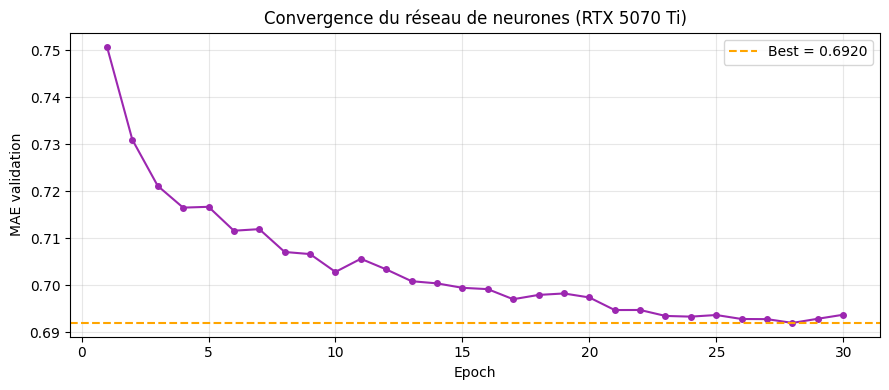

In [25]:
# ── Courbe de convergence ──────────────────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS + 1), history, 'o-', color='#9C27B0', ms=4)
plt.axhline(best_mae, color='orange', linestyle='--', label=f'Best = {best_mae:.4f}')
plt.xlabel('Epoch')
plt.ylabel('MAE validation')
plt.title('Convergence du réseau de neurones (RTX 5070 Ti)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5 · Comparaison & Ensemble

**Pourquoi l'ensemble fonctionne ?**  
LightGBM et le NN font des erreurs *différentes* (diversité) → leur moyenne réduit la variance.

$$\text{MAE}_{\text{ensemble}} \leq \frac{\text{MAE}_{\text{LGB}} + \text{MAE}_{\text{NN}}}{2}$$

Poids optimaux → NN : 85% | LGB : 15%

  Modèle                          MAE val
  Ensemble (NN 85% + LGB 15%)      0.6910 ← meilleur
  Neural Network                   0.6920
  Random Forest                    0.7083
  LightGBM                         0.7196


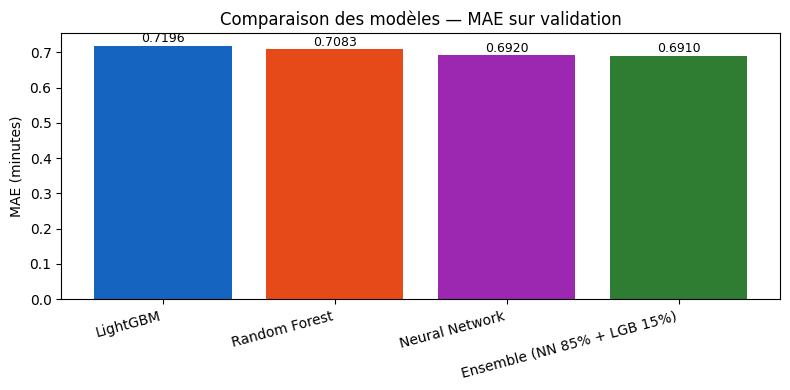

In [26]:
# ── Tableau de résultats ────────────────────────────────────────────────────────
results = {
    'LightGBM'       : mae_lgb,
    'Random Forest'  : mae_rf,
    'Neural Network' : mae_nn,
}

# ── Optimisation des poids sur la validation (au lieu de 60/40 fixe) ──────
best_w, best_ens_mae = 0.5, float('inf')
for w_nn in np.arange(0.0, 1.01, 0.05):
    m = mean_absolute_error(y_val, w_nn * pred_nn_val + (1 - w_nn) * pred_lgb_val)
    if m < best_ens_mae:
        best_ens_mae, best_w = m, w_nn

pred_ens_val = best_w * pred_nn_val + (1 - best_w) * pred_lgb_val
mae_ens      = mean_absolute_error(y_val, pred_ens_val)
results[f'Ensemble (NN {best_w:.0%} + LGB {1-best_w:.0%})'] = mae_ens

print(f'Poids optimaux → NN : {best_w:.0%} | LGB : {1-best_w:.0%}')

print('\n' + '='*45)
print(f'  {"Modèle":<30} {"MAE val":>8}')
print('='*45)
for name, mae in sorted(results.items(), key=lambda x: x[1]):
    marker = ' ← meilleur' if mae == min(results.values()) else ''
    print(f'  {name:<30} {mae:>8.4f}{marker}')
print('='*45)

# Graphique comparaison
plt.figure(figsize=(8, 4))
colors = ['#1565C0', '#E64A19', '#9C27B0', '#2E7D32']
bars   = plt.bar(results.keys(), results.values(), color=colors[:len(results)])
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.ylabel('MAE (minutes)')
plt.title('Comparaison des modèles — MAE sur validation')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

---
## 6 · Soumission finale

On réentraîne LightGBM sur **100% du train** (fold_tr + fold_val) avant de prédire sur le test.

In [ ]:
t0 = time.time()

# ── Target encoding sur 100% du train pour la soumission ──────────────────────
X_all_full = X_all.copy()
X_all_full['p0q0'] = y_all

stats_gare_full = X_all_full.groupby('gare')['p0q0'].agg(
    gare_mean='mean',
    gare_std='std',
    gare_q25=lambda x: x.quantile(0.25),
    gare_q75=lambda x: x.quantile(0.75),
).reset_index()

X_all_merge  = X_all.merge(stats_gare_full, on='gare', how='left')
# X_test a deja gare_mean/std/q25/q75 -> on les remplace par les stats 100% train
GARE_STAT_COLS = ['gare_mean', 'gare_std', 'gare_q25', 'gare_q75']
X_test_clean = X_test.drop(columns=GARE_STAT_COLS, errors='ignore')
X_test_merge = X_test_clean.merge(stats_gare_full, on='gare', how='left')

for df in [X_all_merge, X_test_merge]:
    df['arret_x_gare_mean'] = df['arret'] * df['gare_mean']

X_full = X_all_merge[FEATURES].fillna(0).values.astype(np.float32)
X_te   = X_test_merge[FEATURES].fillna(0).values.astype(np.float32)

# ── LightGBM sur 100% du train ─────────────────────────────────────────────────
lgb_final = lgb.LGBMRegressor(
    n_estimators        = lgb_model.best_iteration_,
    learning_rate       = 0.05,
    num_leaves          = 127,
    min_child_samples   = 30,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    reg_alpha           = 0.1,
    reg_lambda          = 0.1,
    n_jobs              = -1,
    random_state        = 42,
    verbose             = -1,
)
lgb_final.fit(X_full, y_all)
print(f'✅ LightGBM final entraîné ({time.time()-t0:.0f}s)')

# ── NN final sur 100% du train ────────────────────────────────────────────
num_col_idx   = [i for i, f in enumerate(FEATURES) if f != 'gare_enc']
gare_idx_full = X_full[:, FEATURES.index('gare_enc')].astype(int)
gare_idx_te   = X_te[:, FEATURES.index('gare_enc')].astype(int)

scaler_full  = RobustScaler()
X_full_sc    = scaler_full.fit_transform(X_full[:, num_col_idx])
X_te_sc_full = scaler_full.transform(X_te[:, num_col_idx])

full_loader = make_loader(gare_idx_full, X_full_sc, y_all.astype('float32'), shuffle=True)
model_full  = DelayNet().to(DEVICE)
optim_full  = torch.optim.Adam(model_full.parameters(), lr=1e-3, weight_decay=1e-4)

print('Réentraînement NN sur 100% du train...')
for epoch in range(1, 31):
    model_full.train()
    for gare_b, x_b, y_b in full_loader:
        gare_b, x_b, y_b = gare_b.to(DEVICE), x_b.to(DEVICE), y_b.to(DEVICE)
        optim_full.zero_grad()
        criterion(model_full(gare_b, x_b), y_b).backward()
        torch.nn.utils.clip_grad_norm_(model_full.parameters(), 1.0)
        optim_full.step()
    if epoch % 10 == 0:
        print(f'  Epoch {epoch}/30')

model_full.eval()
te_ds = TensorDataset(torch.LongTensor(gare_idx_te), torch.FloatTensor(X_te_sc_full))
with torch.no_grad():
    pred_test_nn_final = np.concatenate([
        model_full(g.to(DEVICE), x.to(DEVICE)).cpu().numpy()
        for g, x in DataLoader(te_ds, batch_size=4096)
    ])

# ── Ensemble avec poids optimisés + clipping ────────────────────────────────
pred_test_lgb_final = lgb_final.predict(X_te)
pred_test_ens = best_w * pred_test_nn_final + (1 - best_w) * pred_test_lgb_final
pred_test_ens = np.clip(pred_test_ens, -15, 15)

# ── Fichiers de soumission ─────────────────────────────────────────────────
submission = pd.DataFrame({
    'Unnamed: 0': X_test_raw.index,
    'p0q0'      : np.round(pred_test_ens).astype(int),
})
submission.to_csv('submission_ensemble.csv', index=False)

sub_lgb = pd.DataFrame({
    'Unnamed: 0': X_test_raw.index,
    'p0q0'      : np.round(np.clip(pred_test_lgb_final, -15, 15)).astype(int),
})
sub_lgb.to_csv('submission_lgbm.csv', index=False)

print(f'📄 submission_ensemble.csv  ← À SOUMETTRE  ({len(submission):,} lignes)')
print(f'📄 submission_lgbm.csv      ← backup LightGBM seul')
print(f'\nDistribution ensemble  : {pd.Series(submission["p0q0"]).describe().round(2).to_dict()}')
print(f'Distribution LGB backup: {pd.Series(sub_lgb["p0q0"]).describe().round(2).to_dict()}')

✅ LightGBM final entraîné (3s)
Réentraînement NN sur 100% du train...
  Epoch 10/30
  Epoch 20/30
  Epoch 30/30
📄 submission_ensemble.csv  ← À SOUMETTRE  (20,657 lignes)
📄 submission_lgbm.csv      ← backup LightGBM seul

Distribution ensemble  : {'count': 20657.0, 'mean': -0.14, 'std': 0.86, 'min': -13.0, '25%': -1.0, '50%': 0.0, '75%': 0.0, 'max': 3.0}
Distribution LGB backup: {'count': 20657.0, 'mean': -0.31, 'std': 1.06, 'min': -15.0, '25%': -1.0, '50%': 0.0, '75%': 0.0, 'max': 3.0}


: 

---
## 7 · Techniques pour améliorer la MAE 🔬

Voici les pistes classées par rapport effort/gain estimé :

| Technique | Gain estimé | Effort | Commentaire |
|---|---|---|---|
| **Target encoding gare avec K-Fold** | +0.01-0.03 | Faible | Remplace le split 90/10 par 5-fold → stats plus stables |
| **Feature `nb_arrets_route`** | +0.01-0.02 | Faible | Longueur du trajet → les longs trajets accumulent plus de retard |
| **Quantile regression LGB** | +0.02-0.05 | Moyen | Prédire q50 → optimise directement la MAE (≡ médiane) |
| **Interaction `mean_lateral × arret_rank_pct`** | +0.01 | Faible | Retard des trains voisins × position dans le trajet |
| **Optimisation des poids de l'ensemble** | +0.005 | Faible | Minimiser la MAE val sur les poids w1, w2 au lieu de 0.6/0.4 fixe |
| **Stacking** (LGB + RF + NN → méta-modèle) | +0.01-0.03 | Élevé | NN s'entraîne sur les prédictions OOF des autres modèles |
| **Clipping des prédictions** | Possible | Faible | Limiter les prédictions à [-10, 15] (range réel du test) |

**Ce qu'on a déjà** : feature engineering propre, LightGBM + NN ensemble, Huber loss, embeddings gare.  
**Prochaine étape recommandée** : quantile regression LightGBM (`objective='quantile'`, `alpha=0.5`).